In [1]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
from typing import Annotated, TypedDict
from langgraph.graph import add_messages
from langgraph.types import interrupt
import logging
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
from langgraph.types import Command
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
import requests
import json
from urllib.parse import urlparse, parse_qs
from langchain_core.messages import AIMessage, ToolMessage
from googleapiclient.discovery import build


logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='query_expansion_agent.log', # Saves to a file
    filemode='a'              # 'a' for append, 'w' to overwrite
)

logger = logging.getLogger(__name__)


In [2]:
load_dotenv(override=True)

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    openai_api_key=os.environ.get("OPENROUTER_API_KEY"),
    openai_api_base="https://openrouter.ai/api/v1"
)

API_KEY = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=API_KEY)

In [3]:

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    level : str
    query : str
    revised_query : str
    serper_results : list[str]
    authority_scores : list[float]
    recommendations : list[str]
    titles : list[str]
    channels : list[str]
    urls : dict[str, str]


In [4]:

def user_level_assessment_node(state : AgentState) -> AgentState:
    logger.info("User Level Assessment Node in Action")
    system_prompt = """You're a language expert and your task is to understand the tone of the query and look for any keywords like beginner, noob, novice, intermediate, expert, advanced etc. If you feel the tone is from beginner you need to respond "BEGINNER", if you feel it is from intermediate you respond "INTERMEDIATE" and "ADVANCED" otherwise. If the query doesn't give you much information about the student level you respond "UNKNOWN". """
    messages = [SystemMessage(system_prompt), HumanMessage(state["query"])]
    response = llm.invoke(messages)
    logger.info(f"Level Assessment - {response.content}")
    return {"messages" : [response], "level" : response.content}


In [5]:
def query_expansion_node(state : AgentState) -> AgentState:
    logger.info("Query Expansion Node in Action")
    system_prompt = (
        f"""You are a Subject Matter Expert in Information Technology and your task is to recommend the right keywords to suggest the youtube videos that are based on student level i.e., Beginner to Advanced, keywords must best match with the provided query. The query is delimited by triple back ticks below
        ```{state["query"]}``` and revise the query as per student's level {state["level"]}. Provide just the final revised query as below:
        Revised Query : <query>
        """
    )
    response = llm.invoke(system_prompt)
    return {"messages" : [response], "revised_query" : response.content}


In [6]:
def confirm_user_level(state : AgentState) -> AgentState:
    level = interrupt(
       {
            "message": "Please provide your understanding level",
            "options": ["BEGINNER", "INTERMEDIATE", "ADVANCED"]
        }
    )
    return {
        "level": level,
    }

In [7]:
def should_continue(state: AgentState) -> str:
    if state["level"] == "UNKNOWN":
        return "confirm_user_level"
    return "query_expansion_node"

In [8]:
def get_video_id(url):
    parsed = urlparse(url)
    return parse_qs(parsed.query).get("v", [None])[0]


def serper_results_node(state: AgentState) -> AgentState:
    url = "https://google.serper.dev/search"
    payload = {
      "q": state["revised_query"].split("-")[-1].strip()
    }
    headers = {
      'X-API-KEY': os.environ["SERPER_API_KEY"],
      'Content-Type': 'application/json'
    }
    videos = []
    urls = {}
    for page in range(0, 6):
        payload["page"] = page + 1
        response = requests.request("POST", url, headers=headers, json=payload)
        results = json.loads(response.text)["organic"]
        for result in results:
            if "youtube.com" in result["link"]:
                videos.append(result["link"])
    video_ids = []
    for video in videos:
        video_id = get_video_id(video)
        video_ids.append(video_id)
        urls[video_id] = video
    return {
        "serper_results" : video_ids,
        "urls" : urls,
        "messages" : [AIMessage(content=f"Videos recommended are : {','.join(video_ids)}")]
    }


In [9]:
def get_counts(video_ids):
    request = youtube.videos().list(
            part="snippet,statistics,contentDetails",
            id=",".join(video_ids)
            )

    response = request.execute()
    video_summaries = {}
    for video in response["items"]:
        views = int(video.get("statistics", {}).get("viewCount", 0))
        likes = int(video.get("statistics", {}).get("likeCount", 0))
        comments = int(video.get("statistics", {}).get("commentCount", 0))
        video_summaries[video["id"]] = {"views" : views, "likes" : likes, "comments" : comments, "title": video["snippet"]["title"], "channelTitle" : video["snippet"]["channelTitle"]}
    return video_summaries

def get_authority_scores(video_ids_dict):
    max_views= max(v['views'] for v in video_ids_dict.values())
    min_views= min(v['views'] for v in video_ids_dict.values())
    max_likes= max(v['likes'] for v in video_ids_dict.values())
    min_likes= min(v['likes'] for v in video_ids_dict.values())
    max_comments= max(v['comments'] for v in video_ids_dict.values())
    min_comments= min(v['comments'] for v in video_ids_dict.values())
    authority_scores_dict = video_ids_dict.copy()
    for video_id in video_ids_dict.keys():
        current_views = video_ids_dict[video_id]['views']
        current_likes = video_ids_dict[video_id]['likes']
        current_comments = video_ids_dict[video_id]['comments']
        normalized_views = (current_views - min_views) / (max_views - min_views)
        normalized_likes = (current_likes - min_likes) / (max_likes - min_likes)
        normalized_comments = (current_comments - min_comments) / (max_comments - min_comments)
        authority_score = 0.5 * normalized_views + 0.3 * normalized_likes + 0.2 * normalized_comments
        authority_scores_dict[video_id]["authority_score"] = round(authority_score,2)
    return authority_scores_dict

def get_video_summaries(authority_scores_dict):
    authority_scores = []
    recommendations = []
    titles = []
    channels = []
    for video_id in authority_scores_dict.keys():
        authority_scores.append(authority_scores_dict[video_id]["authority_score"])
        score = authority_scores_dict[video_id]["authority_score"]
        titles.append(authority_scores_dict[video_id]["title"])
        channels.append(authority_scores_dict[video_id]["channelTitle"])
        if score >= 0.8:
            recommendations.append("recommended as core curriculum material")
        elif score >= 0.6:
            recommendations.append("recommended as primary supporting material")
        elif score >= 0.4:
            recommendations.append("suitable as supplementary learning")
        else:
            recommendations.append("optional reference material")

    return {
        "titles" : titles,
        "channels" : channels,
        "serper_results" : list(authority_scores_dict.keys()),
        "authority_scores" : authority_scores,
        "recommendations" : recommendations
    }

def generate_video_summaries_node(state : AgentState) -> AgentState:
    video_ids_dict = get_counts(state["serper_results"])
    authority_scores_dict = get_authority_scores(video_ids_dict)
    video_summaries = get_video_summaries(authority_scores_dict)
    return video_summaries


In [10]:
def save_results(state : AgentState) -> AgentState:
    serializable_state = state.copy()

    if "messages" in serializable_state:
        serializable_state["messages"] = [
            {"type": type(m).__name__, "content": m.content}
            for m in serializable_state["messages"]
        ]
    serializable_state.pop("messages", None)
    with open("results.json", "w", encoding="utf-8") as f:
        json.dump(serializable_state, f, indent=2)

    return state

In [11]:
workflow = StateGraph(AgentState)

workflow.add_node("user_level_assessment_node", user_level_assessment_node)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("confirm_user_level", confirm_user_level)
workflow.add_node("serper_results_node", serper_results_node)
workflow.add_node("generate_video_summaries_node", generate_video_summaries_node)
workflow.add_node("save_results", save_results)

workflow.set_entry_point("user_level_assessment_node")
workflow.add_edge(START, "user_level_assessment_node")
workflow.add_conditional_edges(
    "user_level_assessment_node",
    should_continue,
    {
        "confirm_user_level": "confirm_user_level",
        "query_expansion_node": "query_expansion_node"
    }
)
workflow.add_edge("confirm_user_level", "query_expansion_node")
workflow.add_edge("query_expansion_node", "serper_results_node")
workflow.add_edge("serper_results_node", "generate_video_summaries_node")
workflow.add_edge("generate_video_summaries_node", "save_results")
workflow.add_edge("save_results", END)
conn = sqlite3.connect("ai_university.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)
app = workflow.compile(checkpointer=memory)

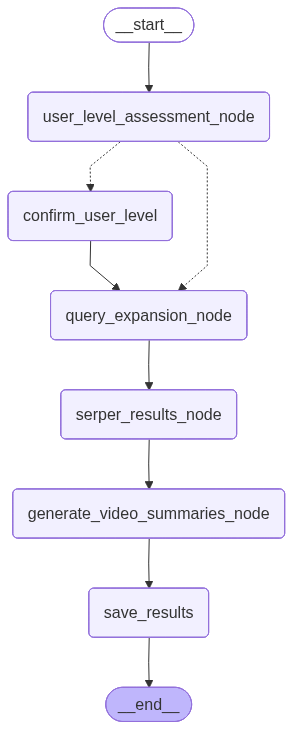

In [12]:
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
valid_levels = ['BEGINNER', 'INTERMEDIATE', 'ADVANCED']
initial_input = {"query" : "Agentic AI"}
config = {"configurable": {"thread_id": 6}}
state = app.invoke(initial_input, config=config)
while "__interrupt__" in state :
    interrupt_info = state["__interrupt__"][0].value

    print(interrupt_info["message"])
    user_input = input("Your answer: ").strip().upper()
    while user_input not in valid_levels:
        print("❌ Invalid input. Please choose one of:", valid_levels)
        user_input = input("Your answer: ").strip().upper()
    state = app.invoke(
        Command(resume=user_input),
        config=config
    )

Please provide your understanding level
